Evaluation Graphs for ANN

In [15]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.event_detection import build_detector, collect_default_data_paths, split_train_test
from src.event_detection_pipeline.model_io import load_detector, save_detector
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc as calc_auc,
    precision_recall_curve,
    average_precision_score,
)

In [16]:
data_dir = ROOT / 'src' / 'data'
paths = collect_default_data_paths(data_dir)
train_paths, test_paths = split_train_test(paths)

print(f'Loaded {len(paths)} SCADA files')
print(f'Train files: {len(train_paths)} | Test files: {len(test_paths)}')

Loaded 20 SCADA files
Train files: 14 | Test files: 6


In [22]:
# confusion matrix for event detection
history = 5
epochs = 12
batch_size = 256
learning_rate = 1e-3

candidate_hidden_sizes = [
    (32,),
    (64, 32),
    (128, 64),
    (128, 64, 32),
]

In [ ]:
# RUN only if you want to overwrite the current detector performance results

# for hidden_sizes in candidate_hidden_sizes:
#     candidate_detector = build_detector(
#         train_paths,
#         history=history,
#         epochs=epochs,
#         batch_size=batch_size,
#         learning_rate=learning_rate,
#         hidden_sizes=hidden_sizes,
#     )

#     save_detector(candidate_detector, directory=f"../results/2026-06-29/detector_{'-'.join(map(str, hidden_sizes))}")


All files saved to /Users/esther/dev/Arsenic-Detection/src/results/2026-06-29/detector_32/

All files saved to /Users/esther/dev/Arsenic-Detection/src/results/2026-06-29/detector_64-32/

All files saved to /Users/esther/dev/Arsenic-Detection/src/results/2026-06-29/detector_128-64-32/


In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.event_detection_pipeline.evaluation import (
    plot_roc_curve_event_detection,
    plot_roc_curve_chlorine_prediction,
    plot_precision_recall_curve,
)


def plot_metrics(result, title_prefix="", chlorine_indices=None):
    if chlorine_indices is None:
        chlorine_indices = [0, 1, 2]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Confusion Matrix
    cm = confusion_matrix(
        result.event_flags.astype(bool),
        result.alarms.astype(bool),
        labels=[False, True],
        normalize="all",
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal", "Event"],
    )
    disp.plot(
        ax=axes[0, 0],
        colorbar=False,
        values_format=".2f",
    )
    axes[0, 0].set_title(f"{title_prefix}Confusion Matrix")

    # 2. Event detection ROC
    plot_roc_curve_event_detection(
        result,
        title=f"{title_prefix}Event Detection ROC",
        ax=axes[0, 1],
    )

    # 3. Chlorine prediction ROC
    plot_roc_curve_chlorine_prediction(
        result,
        chlorine_indices=chlorine_indices,
        title=f"{title_prefix}Chlorine Prediction ROC",
        ax=axes[1, 0],
    )

    # 4. Precision-Recall curve
    plot_precision_recall_curve(
        result,
        title=f"{title_prefix}Precision-Recall Curve",
        ax=axes[1, 1],
    )

    plt.tight_layout()
    plt.show()

    return fig, axes


Detector successfully loaded from /Users/esther/dev/Arsenic-Detection/src/results/2026-06-29/detector_32/
Results for detector with hidden sizes: 32


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
scada_data_4.npz,0.064516,0.494024,0.693878,0.693878,0.516230,-248400.0,527
scada_data_5.npz,0.058520,0.440239,0.693878,0.693878,0.572775,-230400.0,581
scada_data_6.npz,0.074906,0.499004,0.816327,0.816327,0.517277,-253800.0,534


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
mean,0.065981,0.477756,0.734694,0.734694,0.535428,-244200.000000,547.333333
std,0.008291,0.032586,0.070696,0.070696,0.032348,12252.346714,29.365513


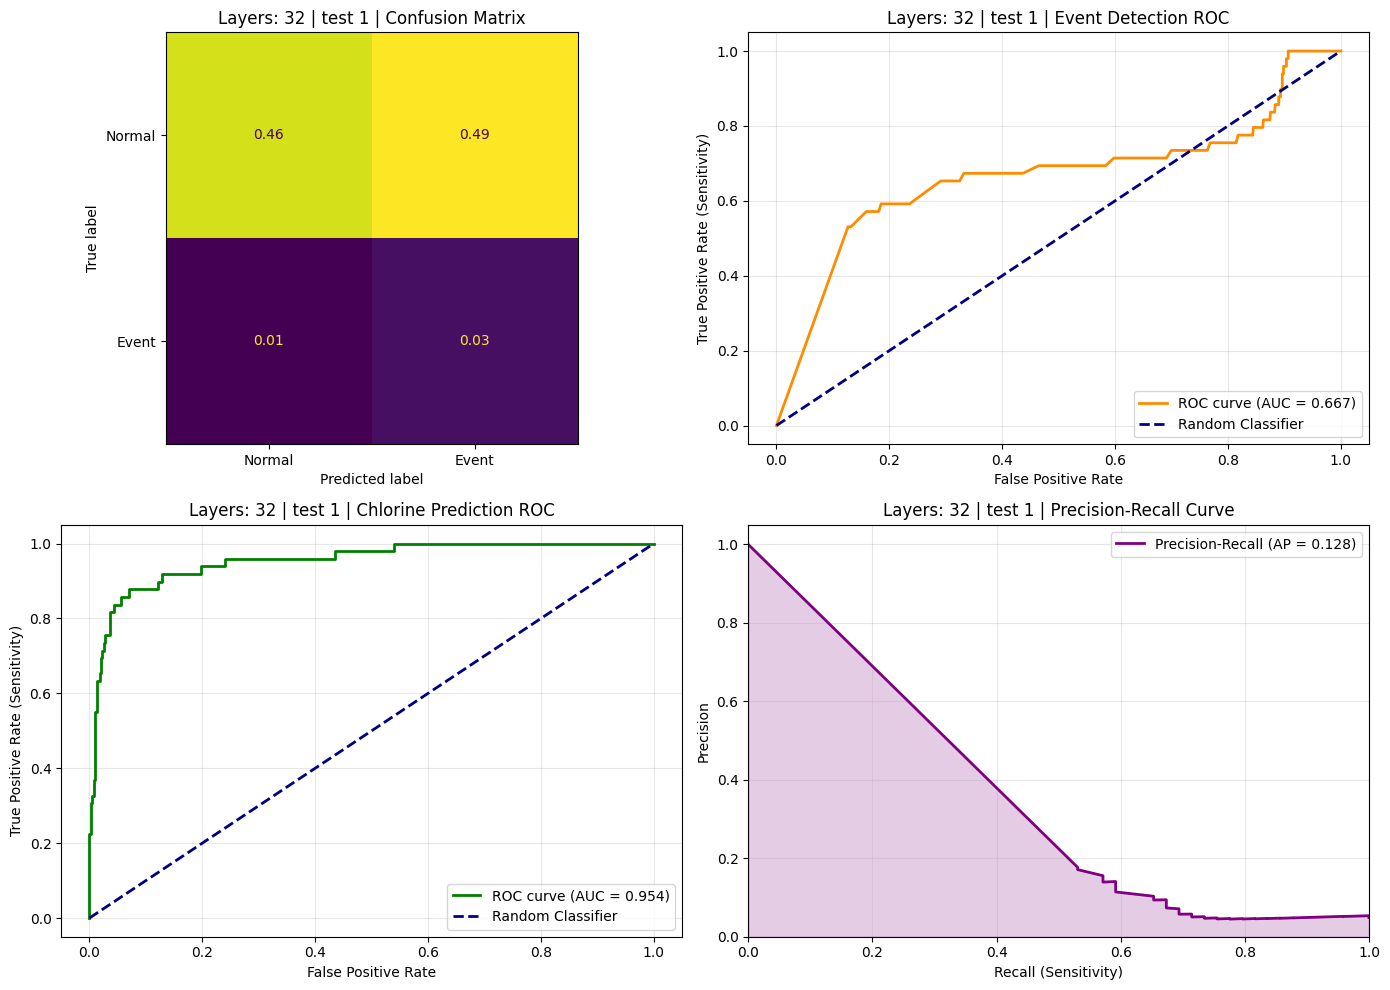

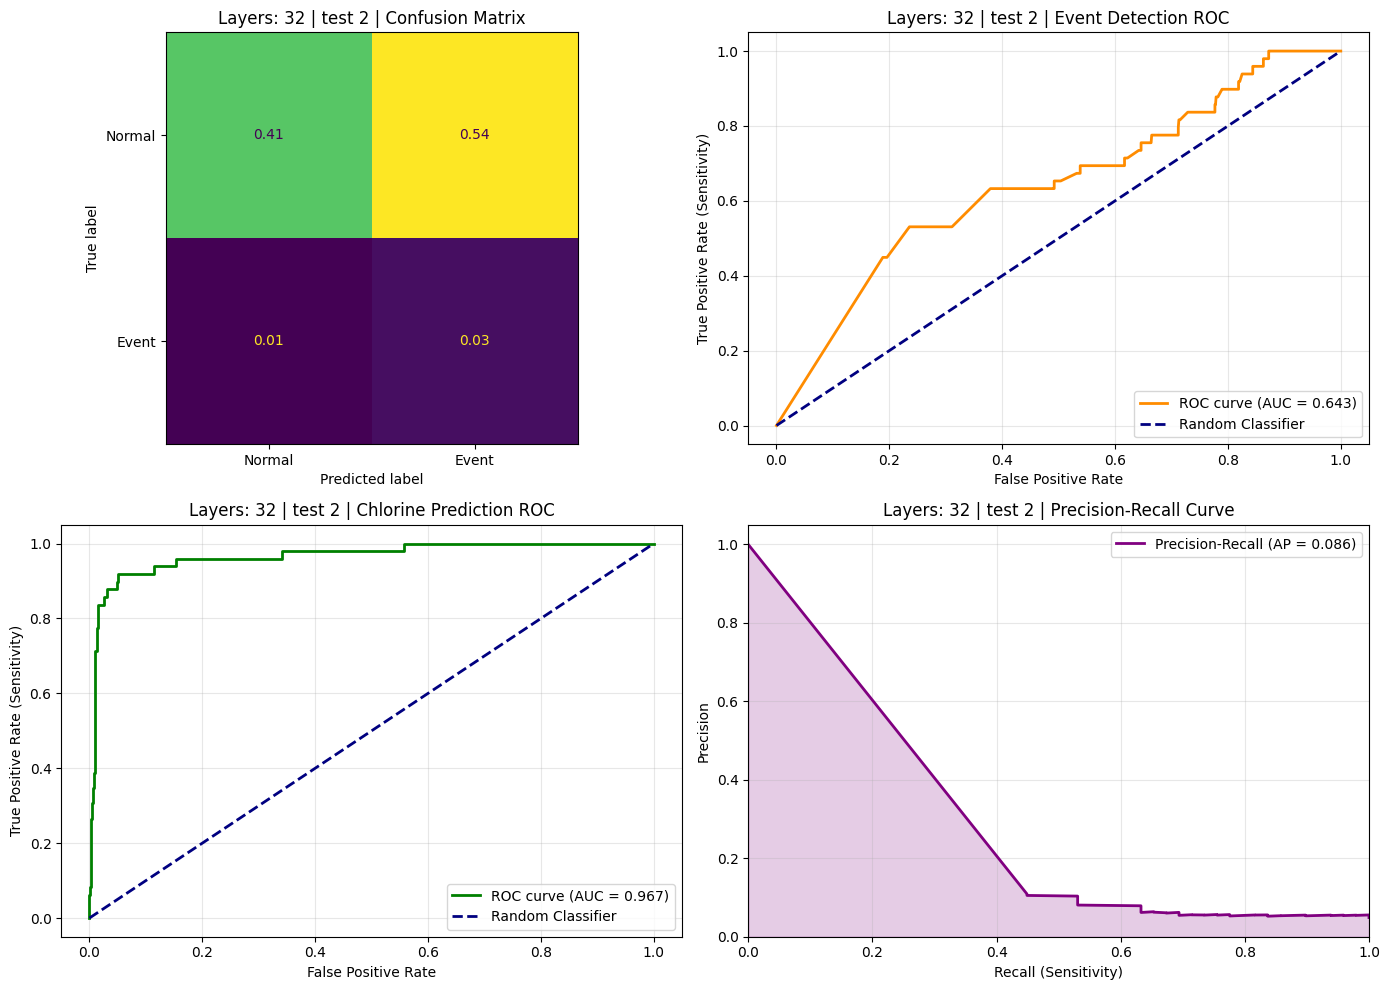

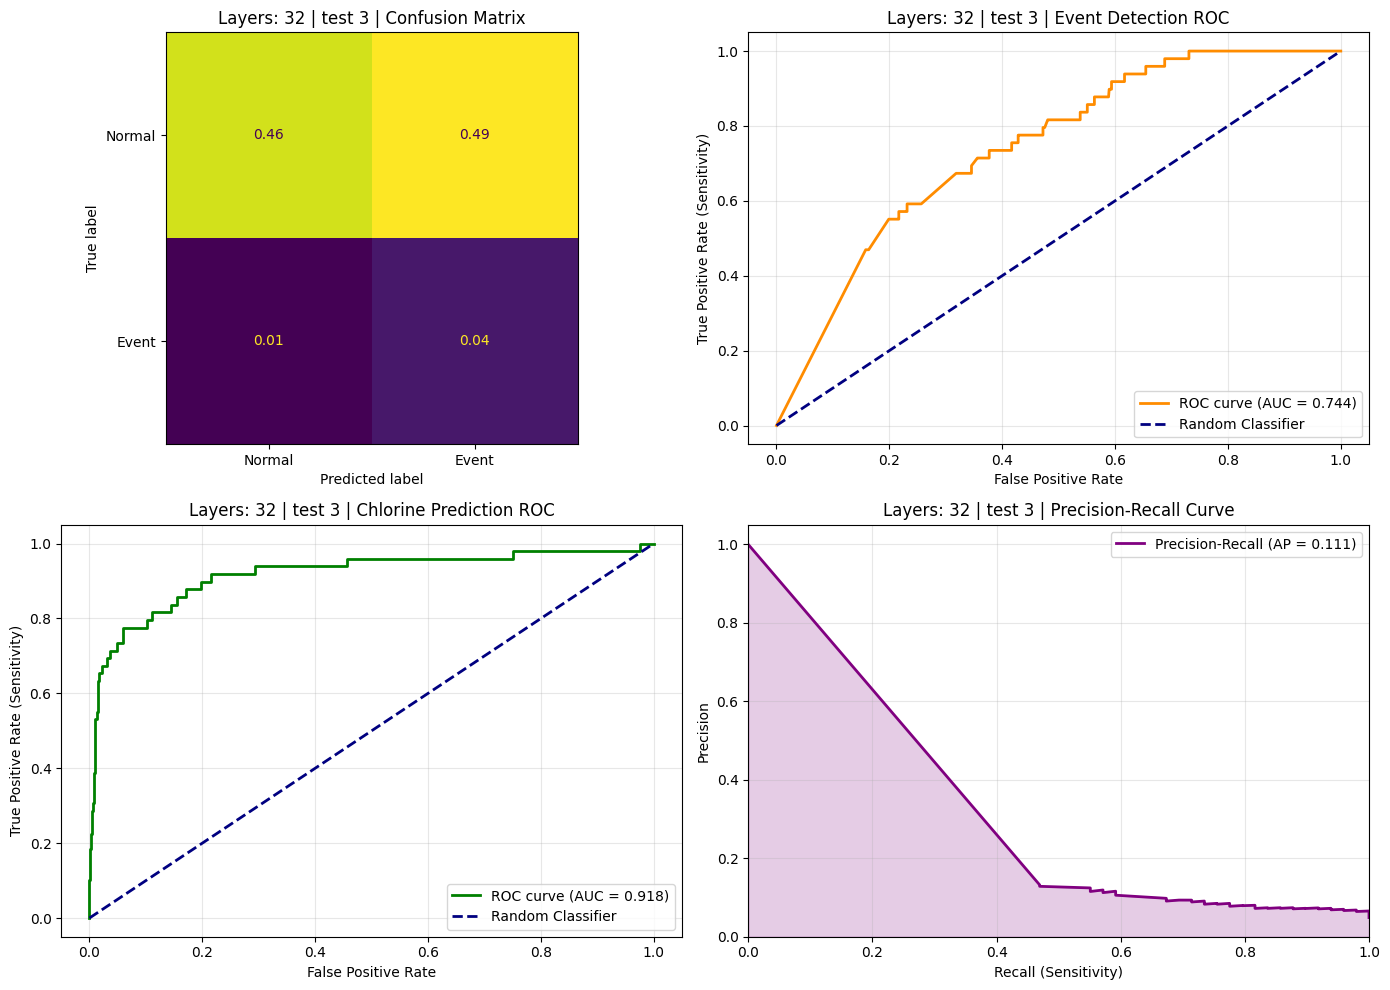


Detector successfully loaded from /Users/esther/dev/Arsenic-Detection/src/results/2026-06-29/detector_64-32/
Results for detector with hidden sizes: 64-32


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
scada_data_4.npz,0.059163,0.342629,0.836735,0.836735,0.682723,-261000.0,693
scada_data_5.npz,0.056548,0.357570,0.775510,0.775510,0.663874,-246600.0,672
scada_data_6.npz,0.063492,0.348606,0.897959,0.897959,0.679581,-259200.0,693


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
mean,0.059734,0.349602,0.836735,0.836735,0.675393,-255600.000000,686.000000
std,0.003507,0.007520,0.061224,0.061224,0.010098,7846.018098,12.124356


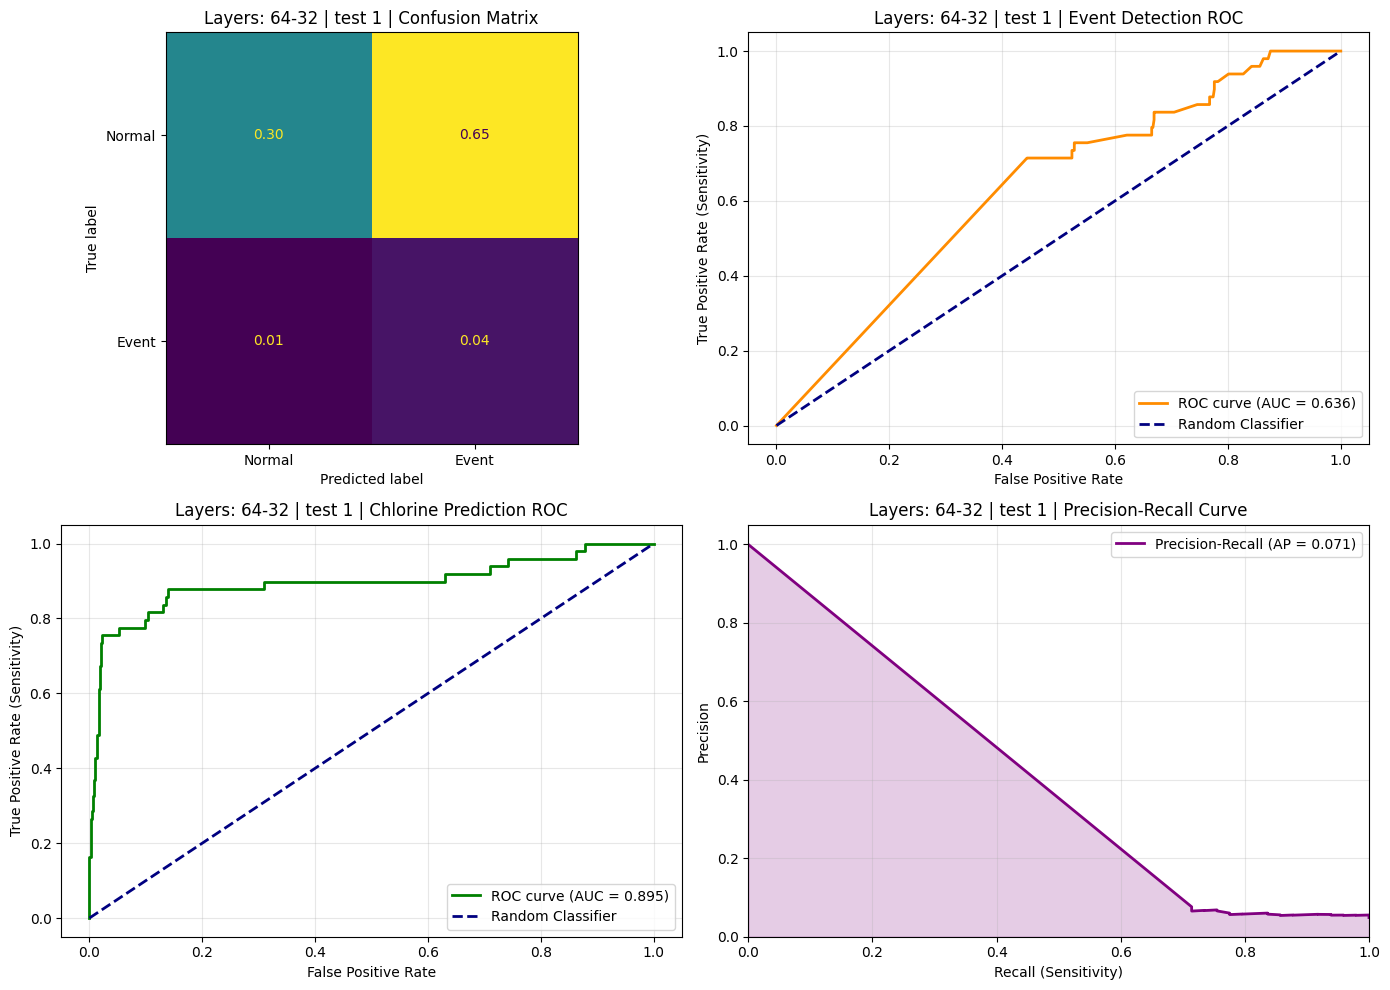

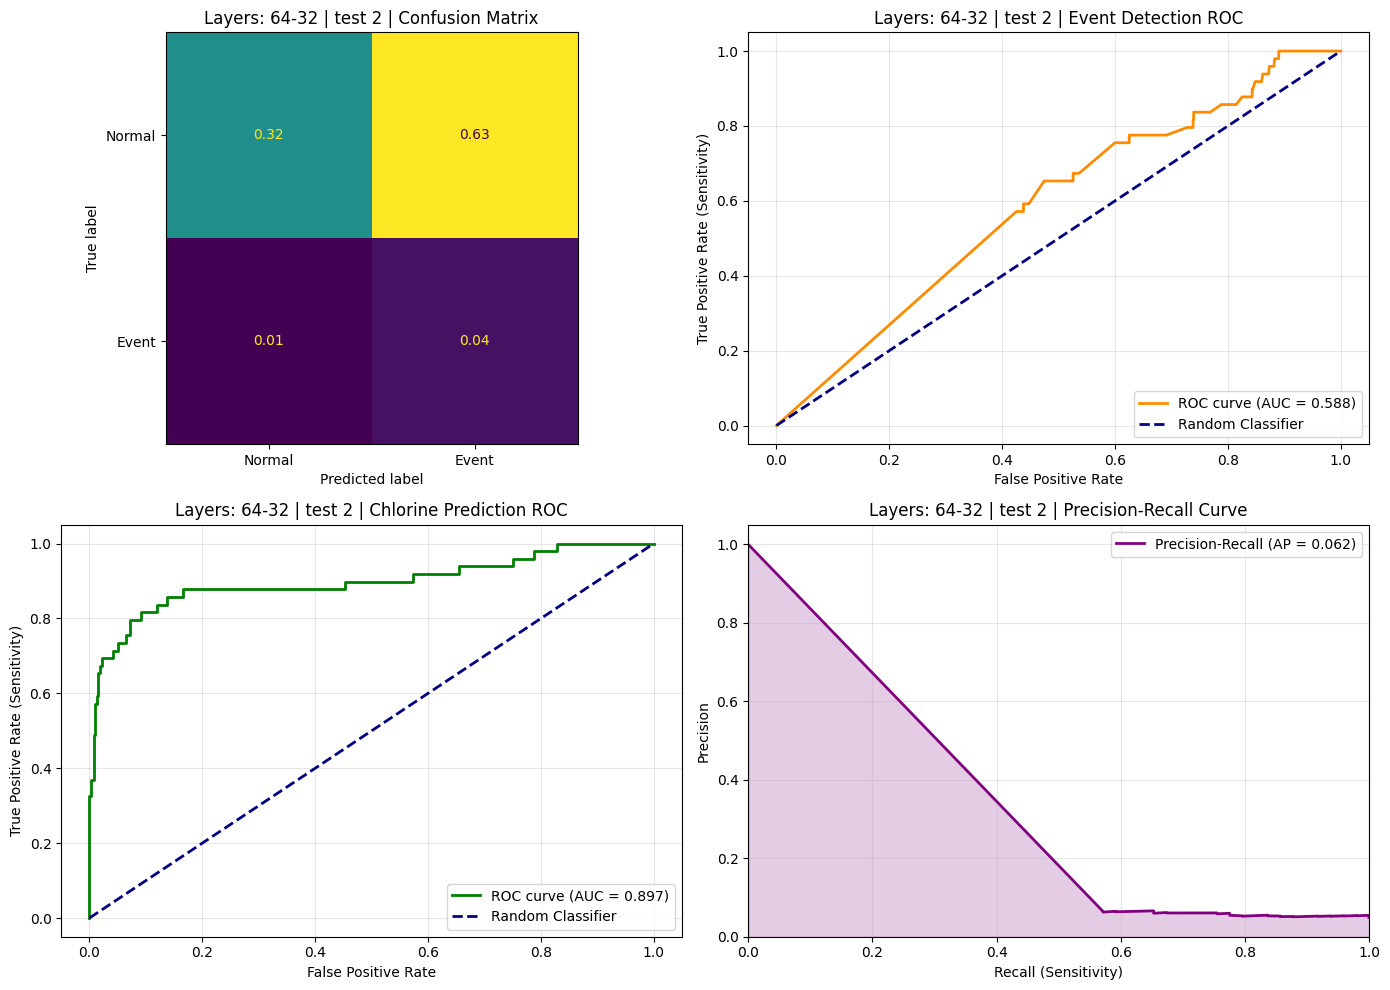

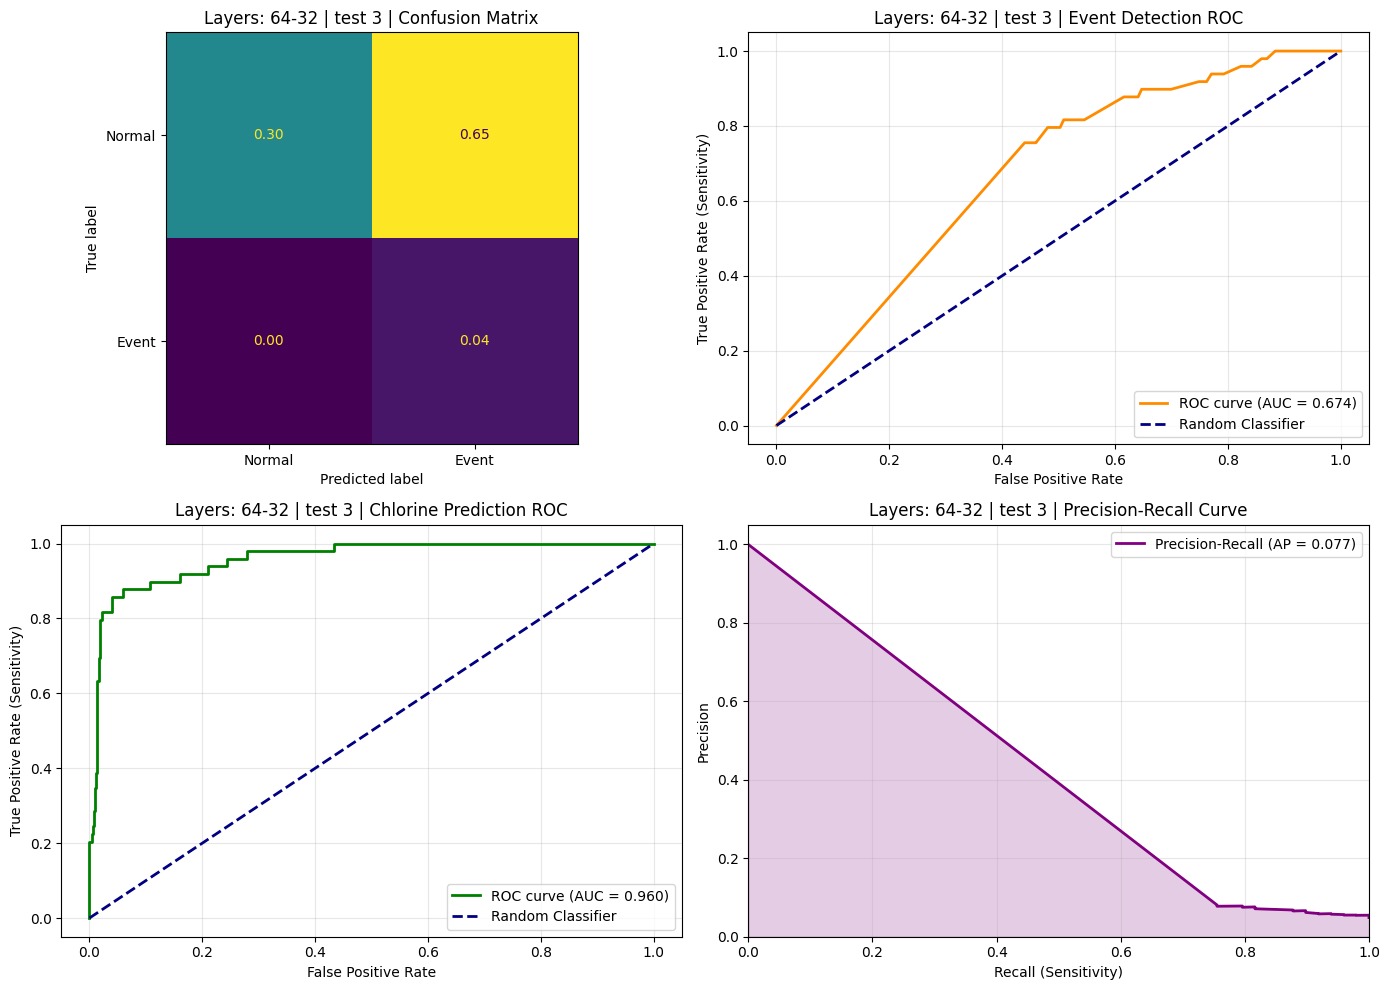


Detector successfully loaded from /Users/esther/dev/Arsenic-Detection/src/results/2026-06-29/detector_128-64/
Results for detector with hidden sizes: 128-64


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
scada_data_4.npz,0.122995,0.670319,0.938776,0.938776,0.343455,-237600.0,374
scada_data_5.npz,0.131579,0.700199,0.918367,0.918367,0.310995,-234000.0,342
scada_data_6.npz,0.115942,0.634462,0.979592,0.979592,0.383246,-244800.0,414


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
mean,0.123505,0.668327,0.945578,0.945578,0.345899,-238800.000000,376.666667
std,0.007831,0.032914,0.031174,0.031174,0.036188,5499.090834,36.073998


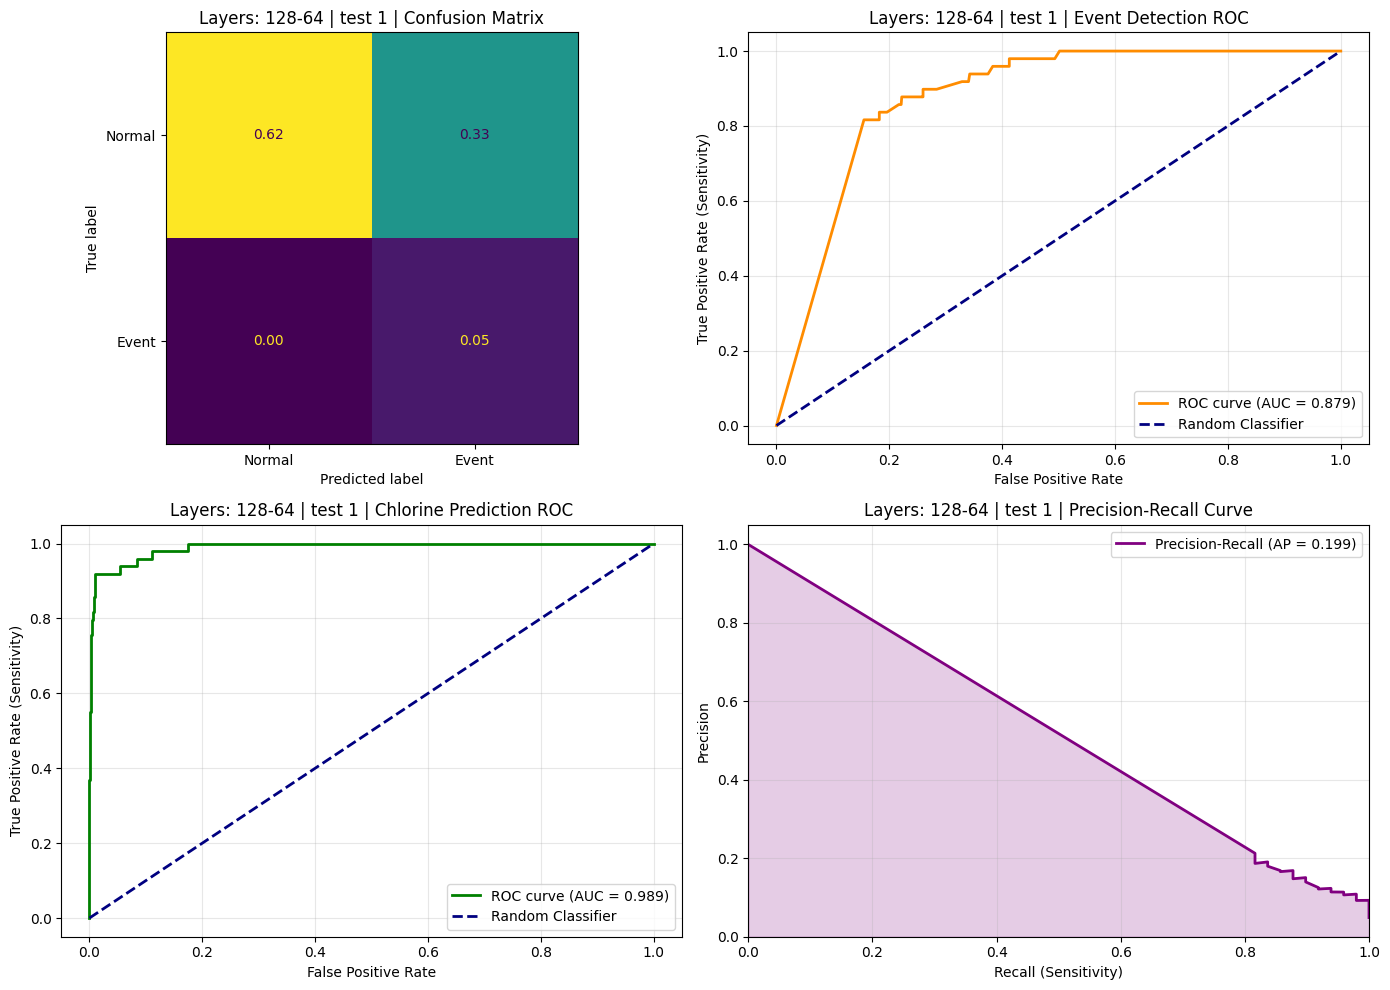

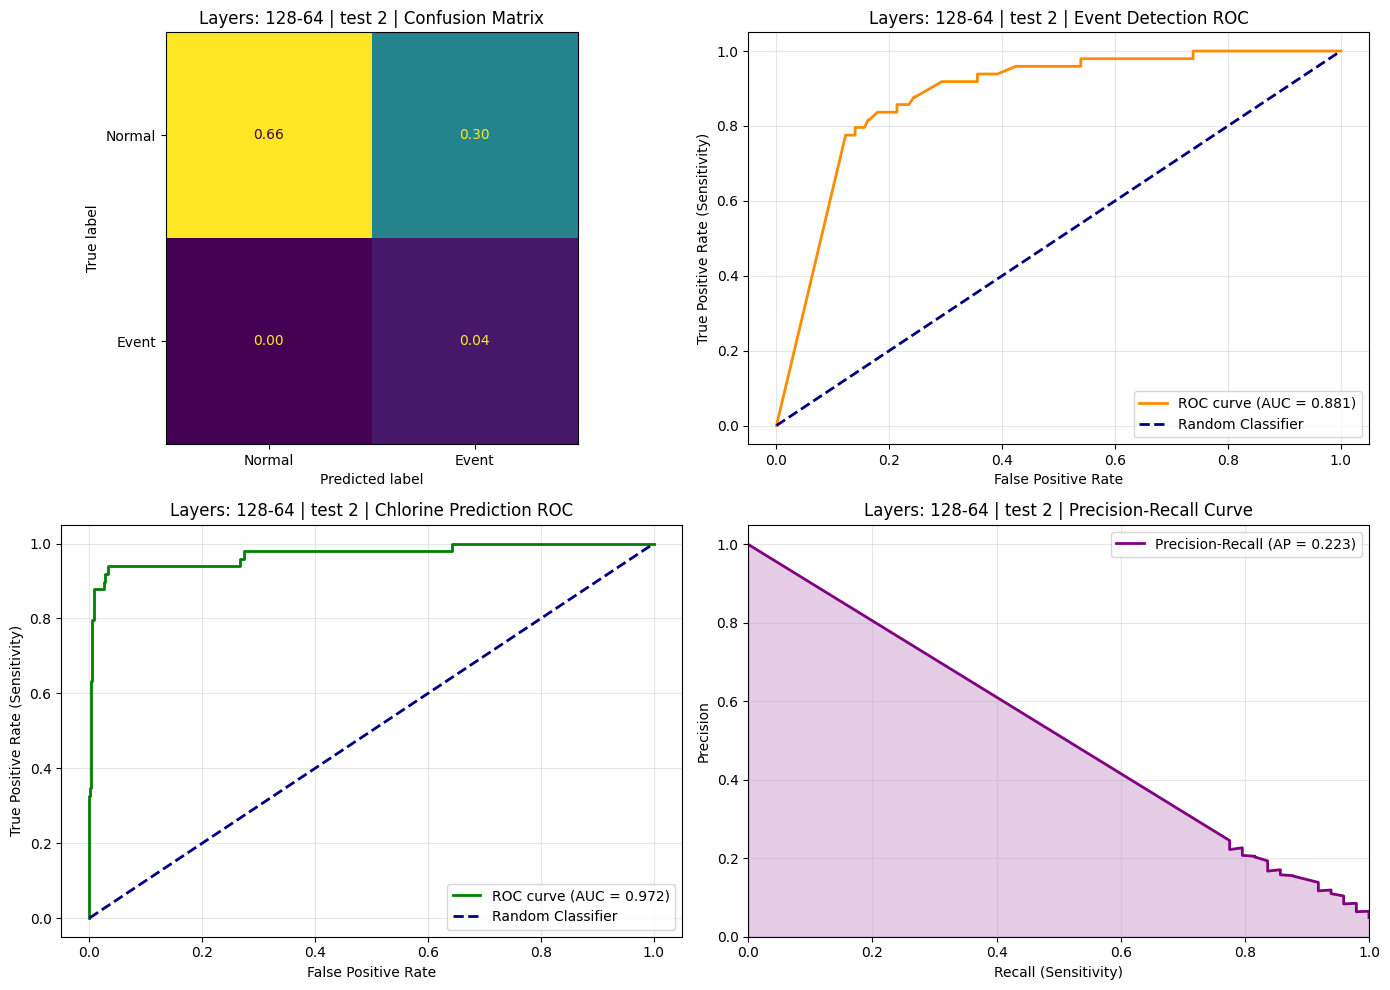

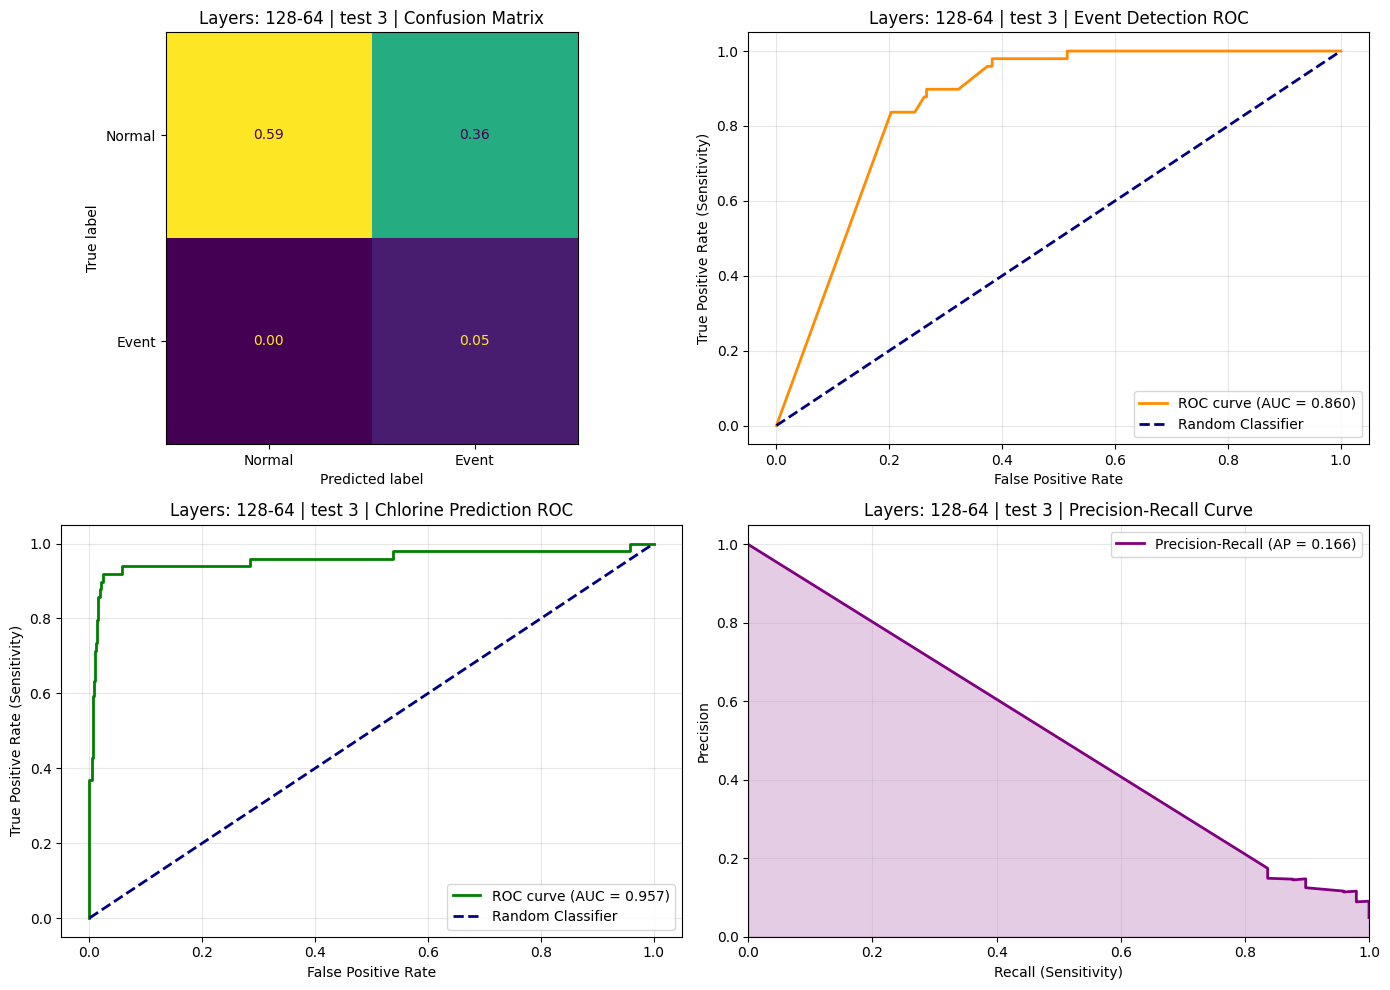


Detector successfully loaded from /Users/esther/dev/Arsenic-Detection/src/results/2026-06-29/detector_128-64-32/
Results for detector with hidden sizes: 128-64-32


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
scada_data_4.npz,0.081996,0.484064,0.938776,0.938776,0.539267,-261000.0,561
scada_data_5.npz,0.090385,0.526892,0.959184,0.959184,0.495288,-250200.0,520
scada_data_6.npz,0.078073,0.445219,0.959184,0.959184,0.581152,-261000.0,602


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
mean,0.083485,0.485392,0.952381,0.952381,0.538569,-257400.000000,561.0
std,0.006289,0.040853,0.011783,0.011783,0.042936,6235.382907,41.0


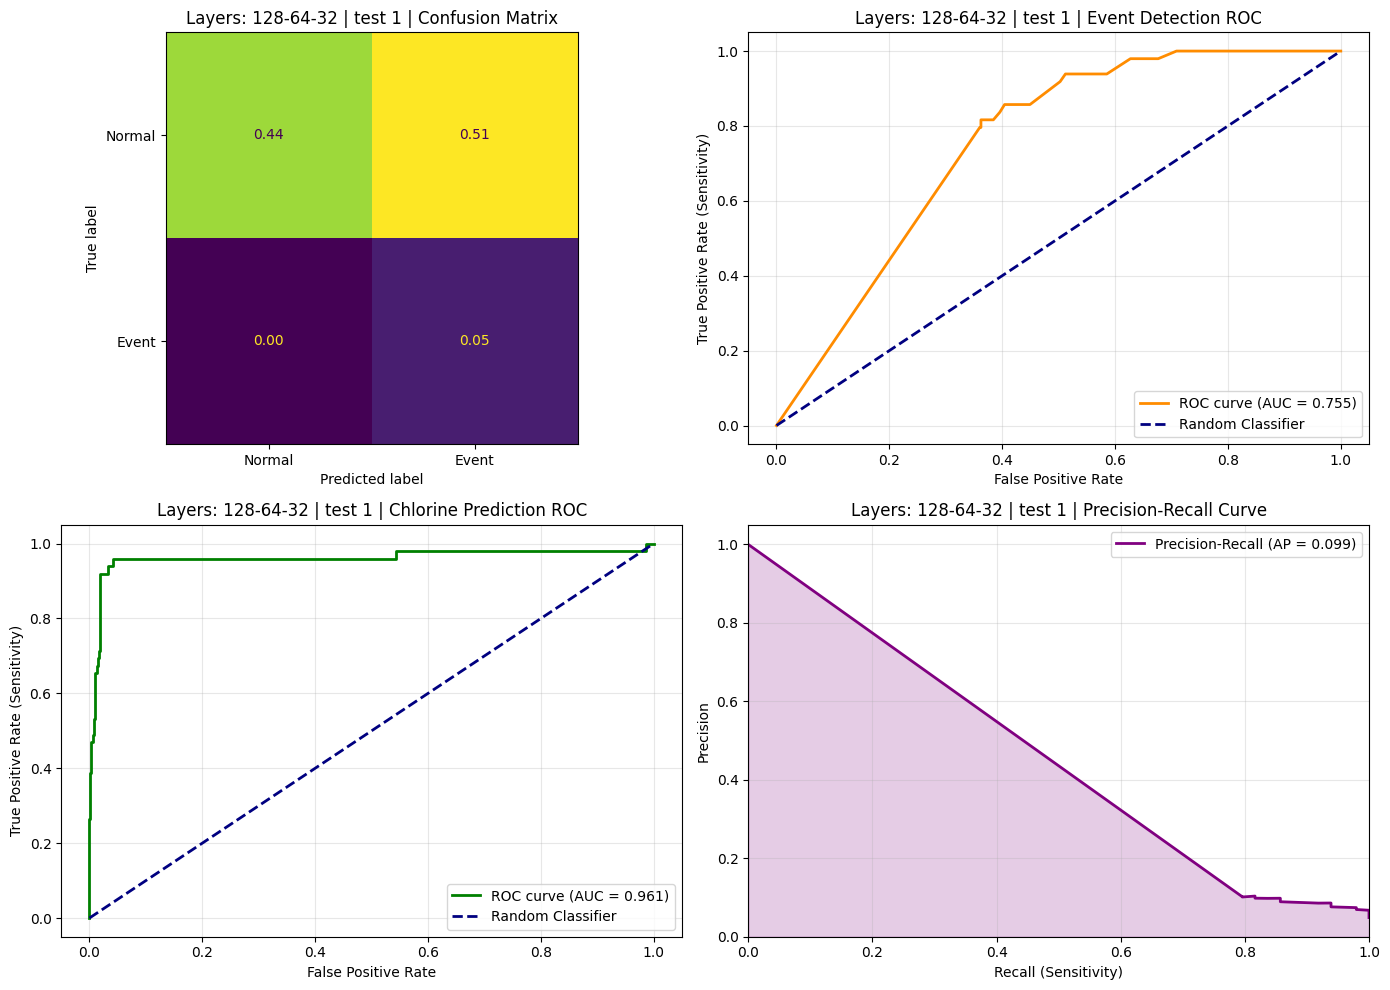

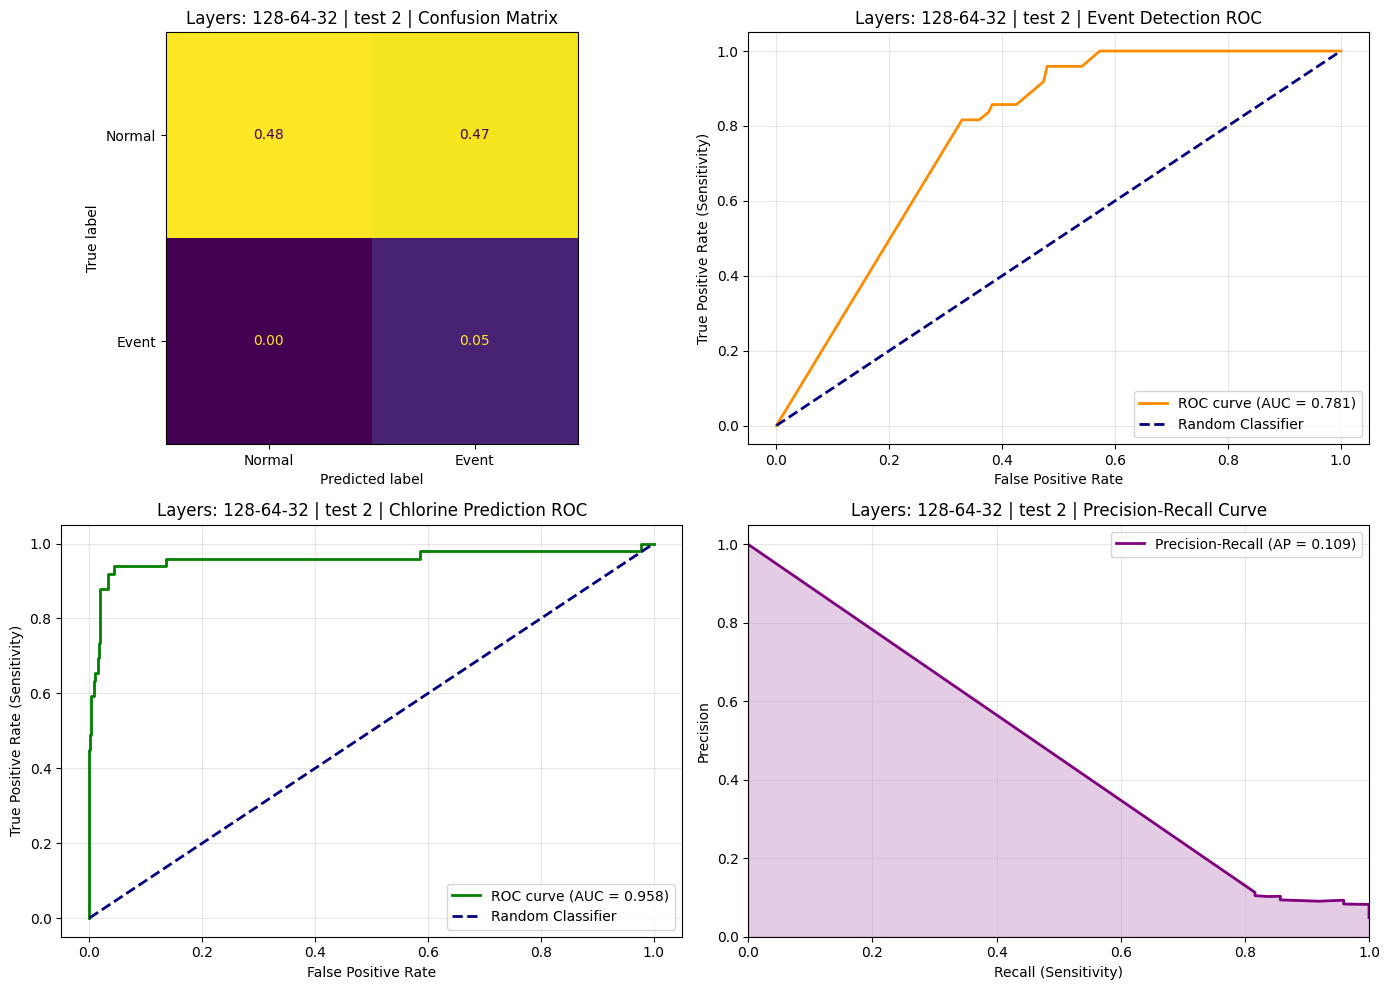

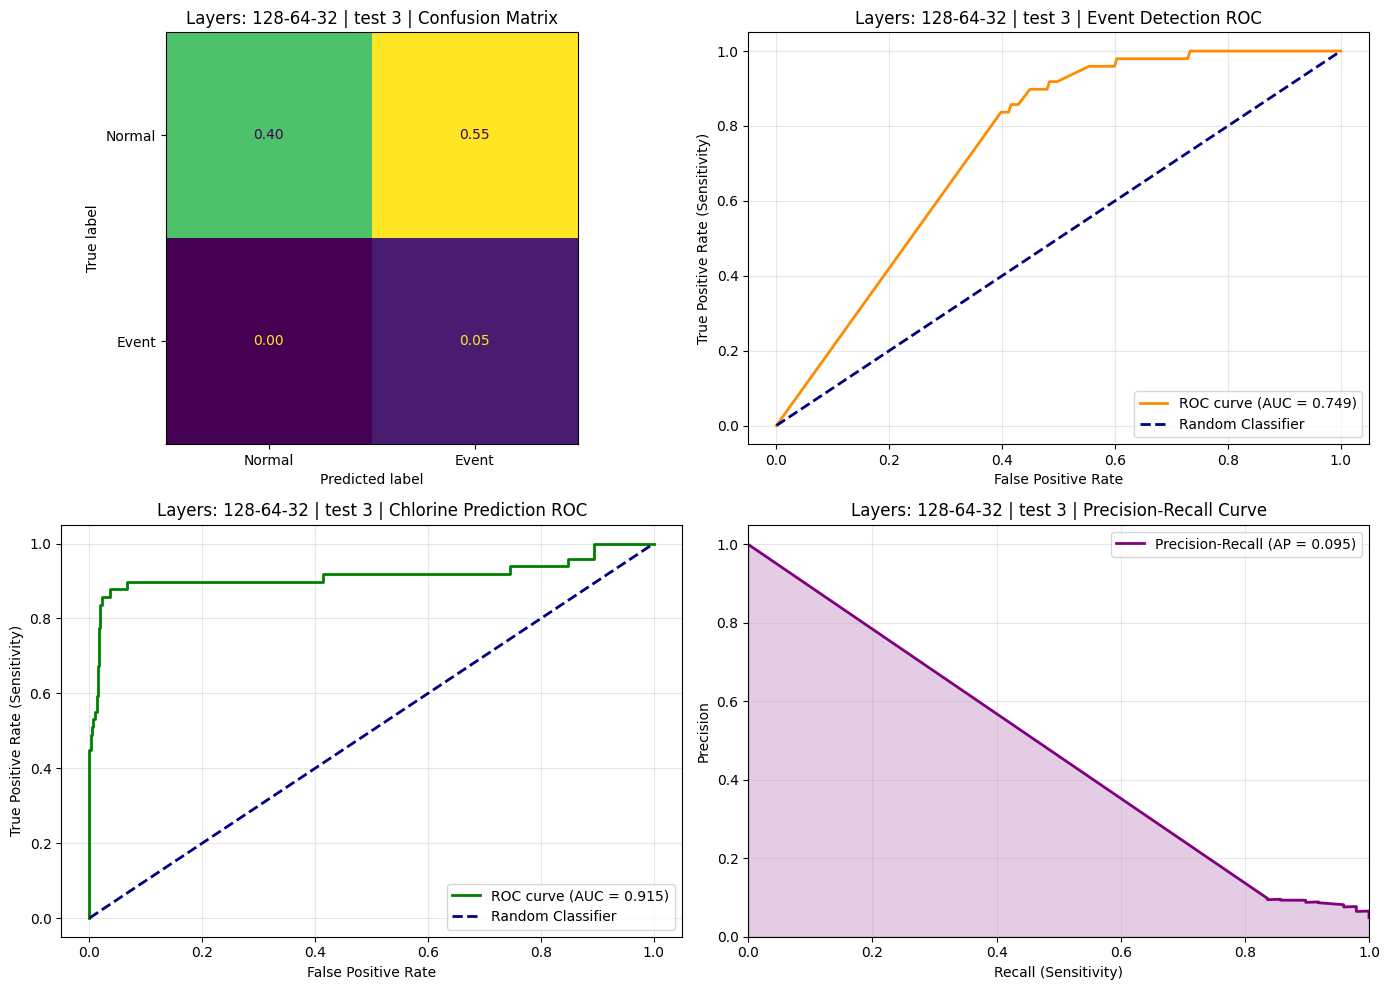

,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
hidden_sizes,,,,,,,
32,0.065981,0.477756,0.734694,0.734694,0.535428,-244200.0,547.333333
64-32,0.059734,0.349602,0.836735,0.836735,0.675393,-255600.0,686.000000
128-64,0.123505,0.668327,0.945578,0.945578,0.345899,-238800.0,376.666667
128-64-32,0.083485,0.485392,0.952381,0.952381,0.538569,-257400.0,561.000000


In [23]:
all_detector_summaries = []
# Use candidate_hidden_sizes to load the saved detectors and run tests on them.
for hidden_sizes in candidate_hidden_sizes:
    hidden_sizes_label = "-".join(map(str, hidden_sizes))
    detector = load_detector(
        directory=f"../results/2026-06-29/detector_{hidden_sizes_label}",
        device="mps",
    )

    selected_test_paths = test_paths[:3]
    results = [detector.detect(path) for path in selected_test_paths]

    print(f"Results for detector with hidden sizes: {hidden_sizes_label}")

    # Keep the three test sets separated.
    summary_df = pd.DataFrame(
        [result.summary() for result in results],
        index=[path.name for path in selected_test_paths],
    )
    display(summary_df)

    # Aggregate metrics across the three test sets.
    aggregated_summary = pd.DataFrame(
        [
            summary_df.mean(numeric_only=True),
            summary_df.std(numeric_only=True),
        ],
        index=["mean", "std"],
    )
    display(aggregated_summary)

    detector_summary = summary_df.mean(numeric_only=True).to_dict()
    detector_summary["hidden_sizes"] = hidden_sizes_label
    all_detector_summaries.append(detector_summary)

    # Plot each test set separately, because each DetectionResult has its own timeline.
    for i, result in enumerate(results):
        plot_metrics(
            result,
            title_prefix=f"Layers: {hidden_sizes_label} | test {i+1} | ",
        )

# Compare all detectors by their mean metrics.
all_detector_summaries_df = pd.DataFrame(all_detector_summaries).set_index("hidden_sizes")
display(all_detector_summaries_df)